In [59]:
import scipy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as cl
import numpy as np
import csv
import time
import pandas as pd
import varray as va
import ldax_processing as ldax
from datetime import datetime
from scipy.optimize import curve_fit, minimize
from scipy.stats import gaussian_kde

In [97]:
# load latest RQ file without amplification
data_lib = '/Users/bfeike/Documents/TPC_RQs'
raw_lib = '/Users/bfeike/Documents/TPC_data'
d0 = va.load(f'{data_lib}/2026-02-10-1641_000006_RQ.vrz')
d1 = va.load(f'{data_lib}/2026-02-12-1657_000000_RQ.vrz')
d2 = va.load(f'{data_lib}/2026-02-13-1001_000000_RQ.vrz')
d3 = va.load(f'{data_lib}/2026-02-16-1156_000008_RQ.vrz')
d4 = va.load(f'{data_lib}/2026-02-19-1538_000014_RQ.vrz')
d5 = va.load(f'{data_lib}/2026-02-28-1347_RQ.vrz')
d6 = va.load(f'{data_lib}/2026-03-02-1346_000000_RQ.vrz')
d7 = va.load(f'{data_lib}/2026-03-02-1526_000000_RQ.vrz')
d8 = va.load(f'{data_lib}/2026-03-03-1200_000000_RQ.vrz')
d9 = va.load(f'{data_lib}/2026-03-04-1315_000000_RQ.vrz')
d10 = va.load(f'{data_lib}/2026-03-05-1339_000000_RQ.vrz')
d11 = va.load(f'{data_lib}/2026-03-05-1710_000000_RQ.vrz')

dlist = [d0, d1, d2, d3, d4, d5, d6, d7, d8, d9, d10, d11]
sets = len(dlist)

In [180]:
ch_arr = np.arange(32)
def spe_cut(d_co, ch_arr, s):
    all_ch_area_co = []
    all_ch_height_co = []
    all_width_co = []
    all_ch_eventids_co = []
    all_ch_pulseids_co = []
    spe_area_co = []
    spe_height_co = []
    spe_width_co = []
    spe_mean_area_co = []
    spe_mean_height_co = []

    #cut_oce = d_co['p_class'] == 3
    
    # Calculate all channel pulse areas and heights with cut applied:
    
    for ch in ch_arr:
        ch_area = d_co['p_area_ch'][:,ch,:].flatten()
        ch_height = d_co['p_height_ch'][:,ch,:].flatten()
        ch_eventid_arr = d_co['p_area_ch'].get_row_index()[:,ch,:].flatten()
        ch_pulseid_arr = d_co['p_area_ch'].get_col_index()[:,ch,:].flatten()

        if s == 4:
            cut_spe = (ch_height < 12) & (ch_height > 5) & (ch_area > 0) & (ch_area < 200)
        elif s == 5:
            cut_spe = (ch_height < 17) & (ch_height > 5) & (ch_area > 0) & (ch_area < 200)
        else:
            cut_spe = (ch_height < 15) & (ch_height > 5) & (ch_area > 0) & (ch_area < 200)
        
        ch_spe_area = ch_area[cut_spe]
        ch_spe_height = ch_height[cut_spe]
        ch_spe_mean_area = np.mean(ch_spe_area)
        ch_spe_mean_height = np.mean(ch_spe_height)

        all_ch_area_co.append(ch_area)
        all_ch_height_co.append(ch_height)
        all_ch_eventids_co.append(ch_eventid_arr)
        all_ch_pulseids_co.append(ch_pulseid_arr)
        spe_area_co.append(ch_spe_area)
        spe_height_co.append(ch_spe_height)
        spe_mean_area_co.append(ch_spe_mean_area)
        spe_mean_height_co.append(ch_spe_mean_height)
        
    return all_ch_area_co, all_ch_height_co, all_ch_eventids_co, all_ch_pulseids_co, spe_area_co, spe_height_co, spe_mean_area_co, spe_mean_height_co

In [102]:
print(np.arange(sets))

[ 0  1  2  3  4  5  6  7  8  9 10 11]


In [99]:
# Error of the mean estimation (Poisson statistics)
def mu_err(spe_area, spe_height, ch_arr):
    sigma_area_arr = []
    sigma_height_arr = []
    stmean_area_arr = []
    stmean_height_arr = []

    for ch in ch_arr:
        n = len(spe_area[ch])
        sigma_area_arr.append(np.std(spe_area[ch]))
        sigma_height_arr.append(np.std(spe_height[ch]))
        stmean_area_arr.append(np.std(spe_area[ch])/np.sqrt(n))
        stmean_height_arr.append(np.std(spe_height[ch])/np.sqrt(n))
        
    return sigma_area_arr, sigma_height_arr, stmean_area_arr, stmean_height_arr

In [182]:
ddict = {}
err_dict = {}
for i in np.arange(sets):
    all_ch_area, all_ch_height, all_ch_eventids, all_ch_pulseids, spe_area, spe_height, spe_mean_area, spe_mean_height, = spe_cut(dlist[i],ch_arr,i)
    ddict[f'{i}'] = [all_ch_area, all_ch_height, all_ch_eventids, all_ch_pulseids, spe_area, spe_height, spe_mean_area, spe_mean_height]
    sigma_area_arr, sigma_height_arr, stmean_area_arr, stmean_height_arr = mu_err(spe_area, spe_height, ch_arr)
    err_dict[f'{i}'] = [sigma_area_arr, sigma_height_arr, stmean_area_arr, stmean_height_arr]

In [105]:
# Fit functions

def Gaussian(x, peak, sigma, mu):
    return(peak*(1/(sigma*np.sqrt(2*np.pi)))*np.exp((-(x-mu)**2/(2*sigma**2))))

def area_func(v, a, vbrk):
    return a*(v-vbrk)

def gaussfit(volts, ch_arr):
    pres = np.zeros((32, 3))
    prescov = np.zeros((32,3,3))
    err_mean_area = np.zeros((32))
    for ch in ch_arr:
        fig, axs = plt.subplots(nrows=16, ncols=2);
        ax = axs.flatten();
        counts, bins, patches = ax[ch].hist(ddict[f'{volts}'][4][ch], edgecolor='black', bins=100, range=[20,50e1]);
        plt.close()
        bins = (bins[:-1]+bins[1:])/2
        popt, pcov = curve_fit(Gaussian,xdata=bins,ydata=counts,p0=(100,20,100),sigma=err_dict[f'{volts}'][0][ch],bounds=([0,0,0],[100000,100,1000]),maxfev=10000)
        pres[ch] = popt
        prescov[ch] = pcov
        err_mean_area[ch] = pcov[2,2]
        
    return pres, prescov, err_mean_area
    
def linfit(v_bias, mu_area, sigmar, ch_arr):
    pbias = np.zeros((32,2))
    pcov = np.zeros((32,2,2))
    for ch in ch_arr:
        v_b, v_b_cov = curve_fit(area_func,xdata=v_bias,ydata=mu_area[:,ch,2],p0=(25,25),sigma=np.sqrt(sigmar[:,ch]),bounds=([-100,-100],[100,100]),maxfev=10000)
        pbias[ch] = v_b
        pcov[ch] = v_b_cov
        
    return pbias, pcov

In [181]:
pres = np.zeros((sets,32,3))
prescov = np.zeros((sets,32,3,3))
err_mean_area = np.zeros((sets,32))

for i in np.arange(sets):
    res, cov, err = gaussfit(i, ch_arr)
    pres[i] = res
    prescov[i] = cov
    err_mean_area[i] = err

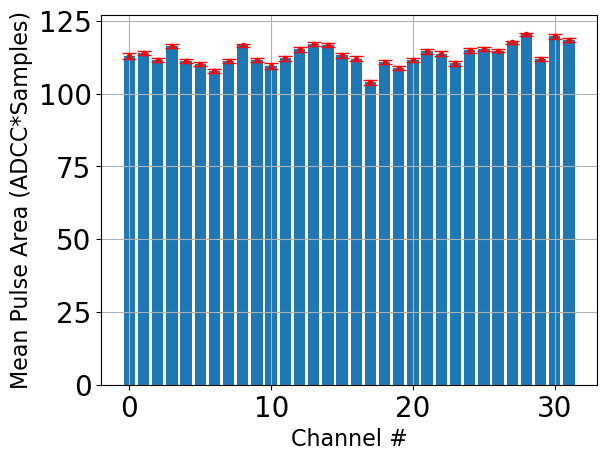

Channel 0: 112.87 +/- 0.921
Channel 1: 113.93 +/- 0.783
Channel 2: 111.5 +/- 0.744
Channel 3: 116.32 +/- 0.83
Channel 4: 111.1 +/- 0.725
Channel 5: 110.17 +/- 0.748
Channel 6: 107.88 +/- 0.69
Channel 7: 111.12 +/- 0.695
Channel 8: 116.55 +/- 0.624
Channel 9: 111.57 +/- 0.807
Channel 10: 109.5 +/- 0.974
Channel 11: 112.13 +/- 0.819
Channel 12: 115.16 +/- 0.718
Channel 13: 117 +/- 0.63
Channel 14: 116.71 +/- 0.793
Channel 15: 113.13 +/- 0.85
Channel 16: 112.02 +/- 0.837
Channel 17: 103.9 +/- 0.814
Channel 18: 110.78 +/- 0.716
Channel 19: 108.72 +/- 0.718
Channel 20: 111.42 +/- 0.717
Channel 21: 114.5 +/- 0.728
Channel 22: 113.73 +/- 0.777
Channel 23: 110.34 +/- 0.803
Channel 24: 114.84 +/- 0.852
Channel 25: 115.23 +/- 0.667
Channel 26: 114.8 +/- 0.613
Channel 27: 117.58 +/- 0.634
Channel 28: 120.31 +/- 0.608
Channel 29: 111.92 +/- 0.769
Channel 30: 119.62 +/- 0.778
Channel 31: 118.51 +/- 0.689


In [107]:
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.bar(ch_arr, pres[0,:,2])
plt.errorbar(ch_arr, pres[0,:,2], yerr=np.sqrt(err_mean_area[0]), color='r', fmt='.', capsize=5)
plt.grid()
plt.xlabel('Channel #', fontsize=16)
plt.ylabel('Mean Pulse Area (ADCC*Samples)', fontsize=16)
#plt.savefig('Mu_SPE_Area_Err_Co57')
plt.show()
for ch in ch_arr:
    print(f'Channel {ch}: {pres[0,ch,2]:.5g} +/- {np.sqrt(err_mean_area[0,ch]):.3g}')

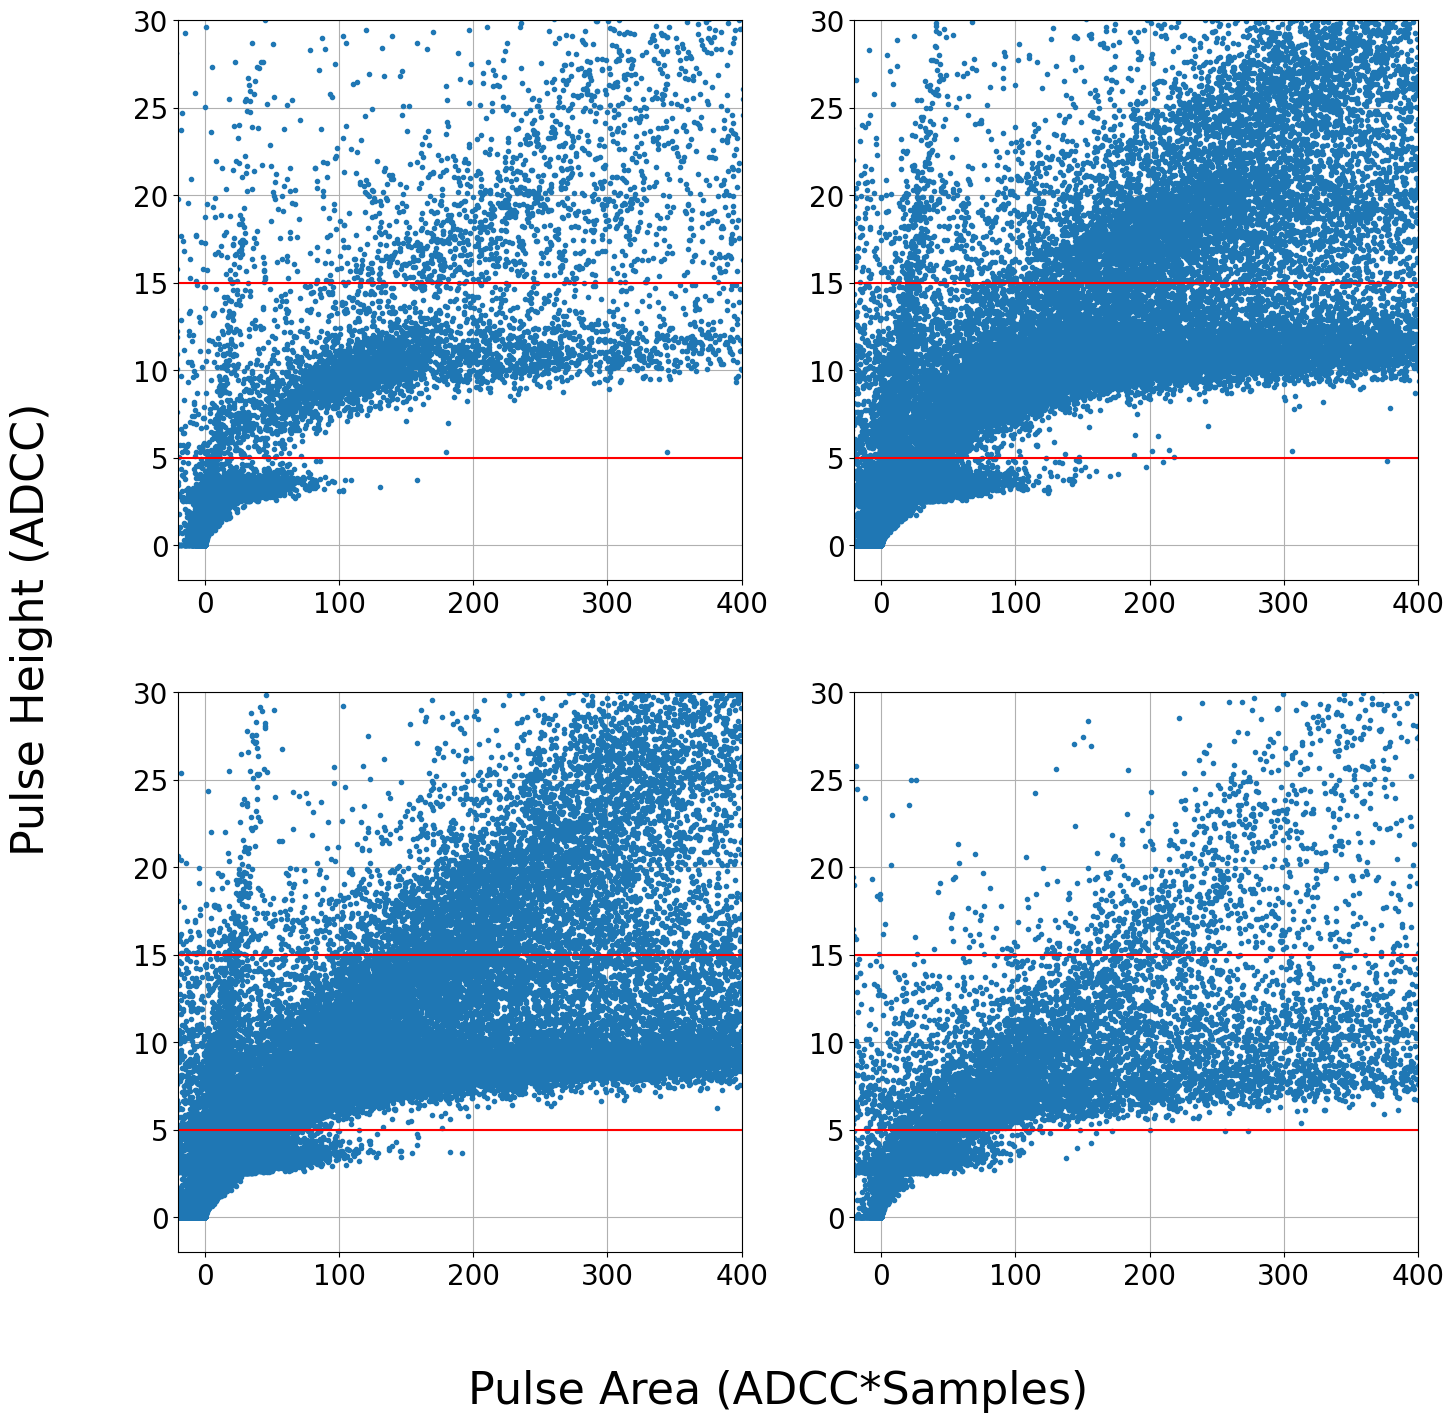

In [11]:
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
x0 = 0
x1 = 200
y0 = 15
y1 = 5
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16,16))
for i in np.arange(len(axs)+2):
    ax = axs.flatten()
    ax[i].plot(ddict[f'{i}'][0][0], ddict[f'{i}'][1][0],'.')
    #ax[i].plot(np.r_[180,250,250,180,180],np.r_[17.5,17.5,20.0,20.0,17.5],'r-',lw=1)
    ax[i].axline((x0, y0), (x1, y0), color='r')
    ax[i].axline((x0, y1), (x1, y1), color='r')
    ax[i].set_xlim(-20, 400)
    ax[i].set_ylim(-2, 30)
    ax[i].grid()
fig.supxlabel('Pulse Area (ADCC*Samples)', fontsize=32)
fig.supylabel('Pulse Height (ADCC)', fontsize=32)
plt.show()

cut_ch_eventids = []
cut_ch_pulseids = []
#for i in np.arange(4):
    #for k in np.arange(32):
        #eventids = ddict[f'{i}'][2][k]
        #pulseids = ddict[f'{i}'][3][k]
        #cut_box = (ddict[f'{i}'][0][k]>180)&(ddict[f'{i}'][0][k]<250)&(ddict[f'{i}'][1][k]>17.5)&(ddict[f'{i}'][1][k]<20.0)
        #cut_ch_eventids.append(eventids[cut_box])
        #cut_ch_pulseids.append(pulseids[cut_box])

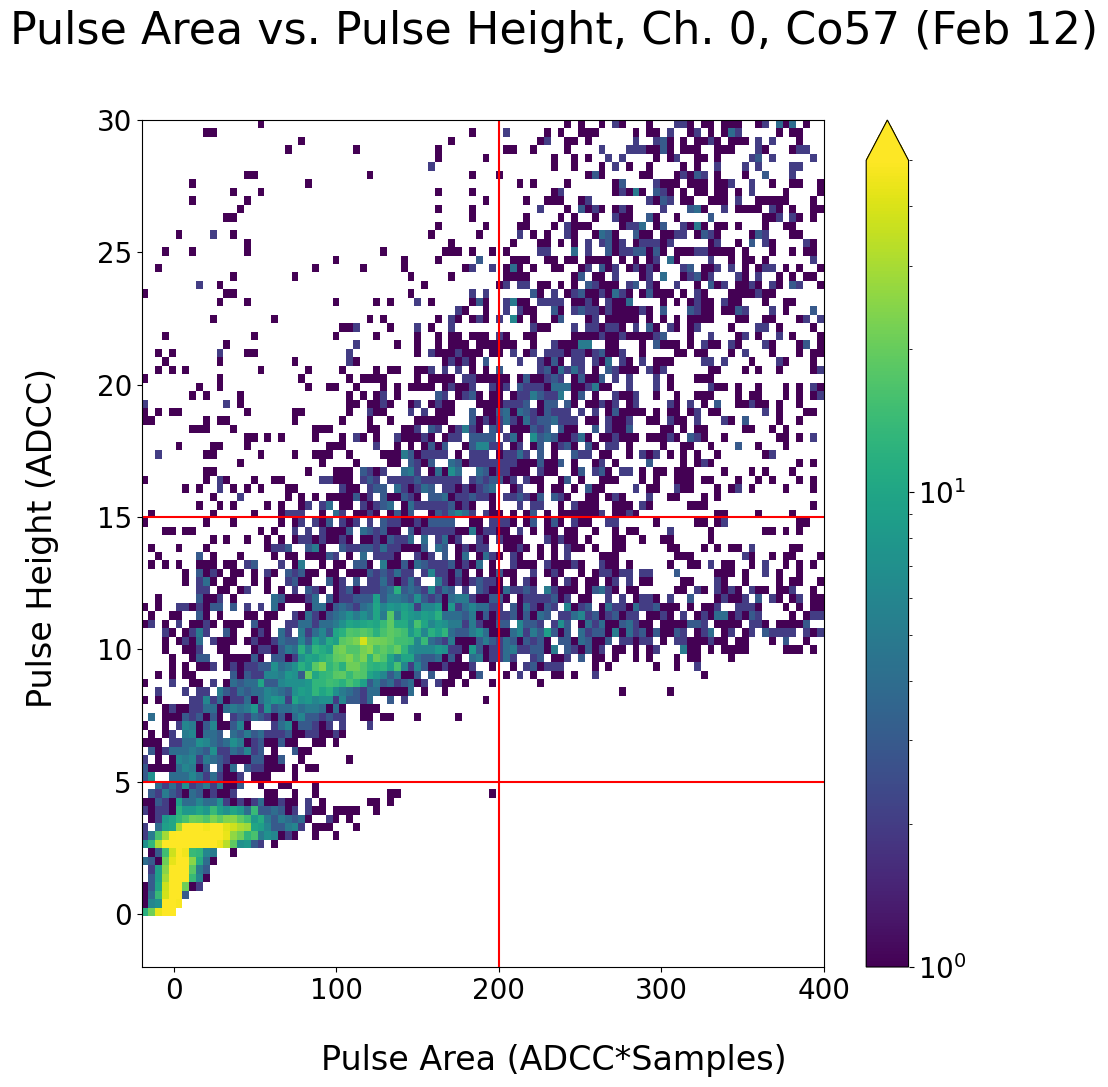

In [202]:
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
x0 = 0
x1 = 200
y0 = 15
y1 = 5
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(11,11))
h = axs.hist2d(ddict['0'][0][0], ddict['0'][1][0], bins=100, range=[[-20,400],[-2,30]], cmap='viridis', norm=cl.LogNorm(1,50))
axs.axvline(x=200,color='r')
axs.axline((x0,y0),(x1,y0),color='r')
axs.axline((x0,y1),(x1,y1),color='r')
fig.colorbar(h[3], ax=axs, extend='max')
fig.supxlabel('Pulse Area (ADCC*Samples)', fontsize=24)
fig.supylabel('Pulse Height (ADCC)', fontsize=24)
fig.suptitle('Pulse Area vs. Pulse Height, Ch. 0, Co57 (Feb 12)', fontsize=32)
plt.show()

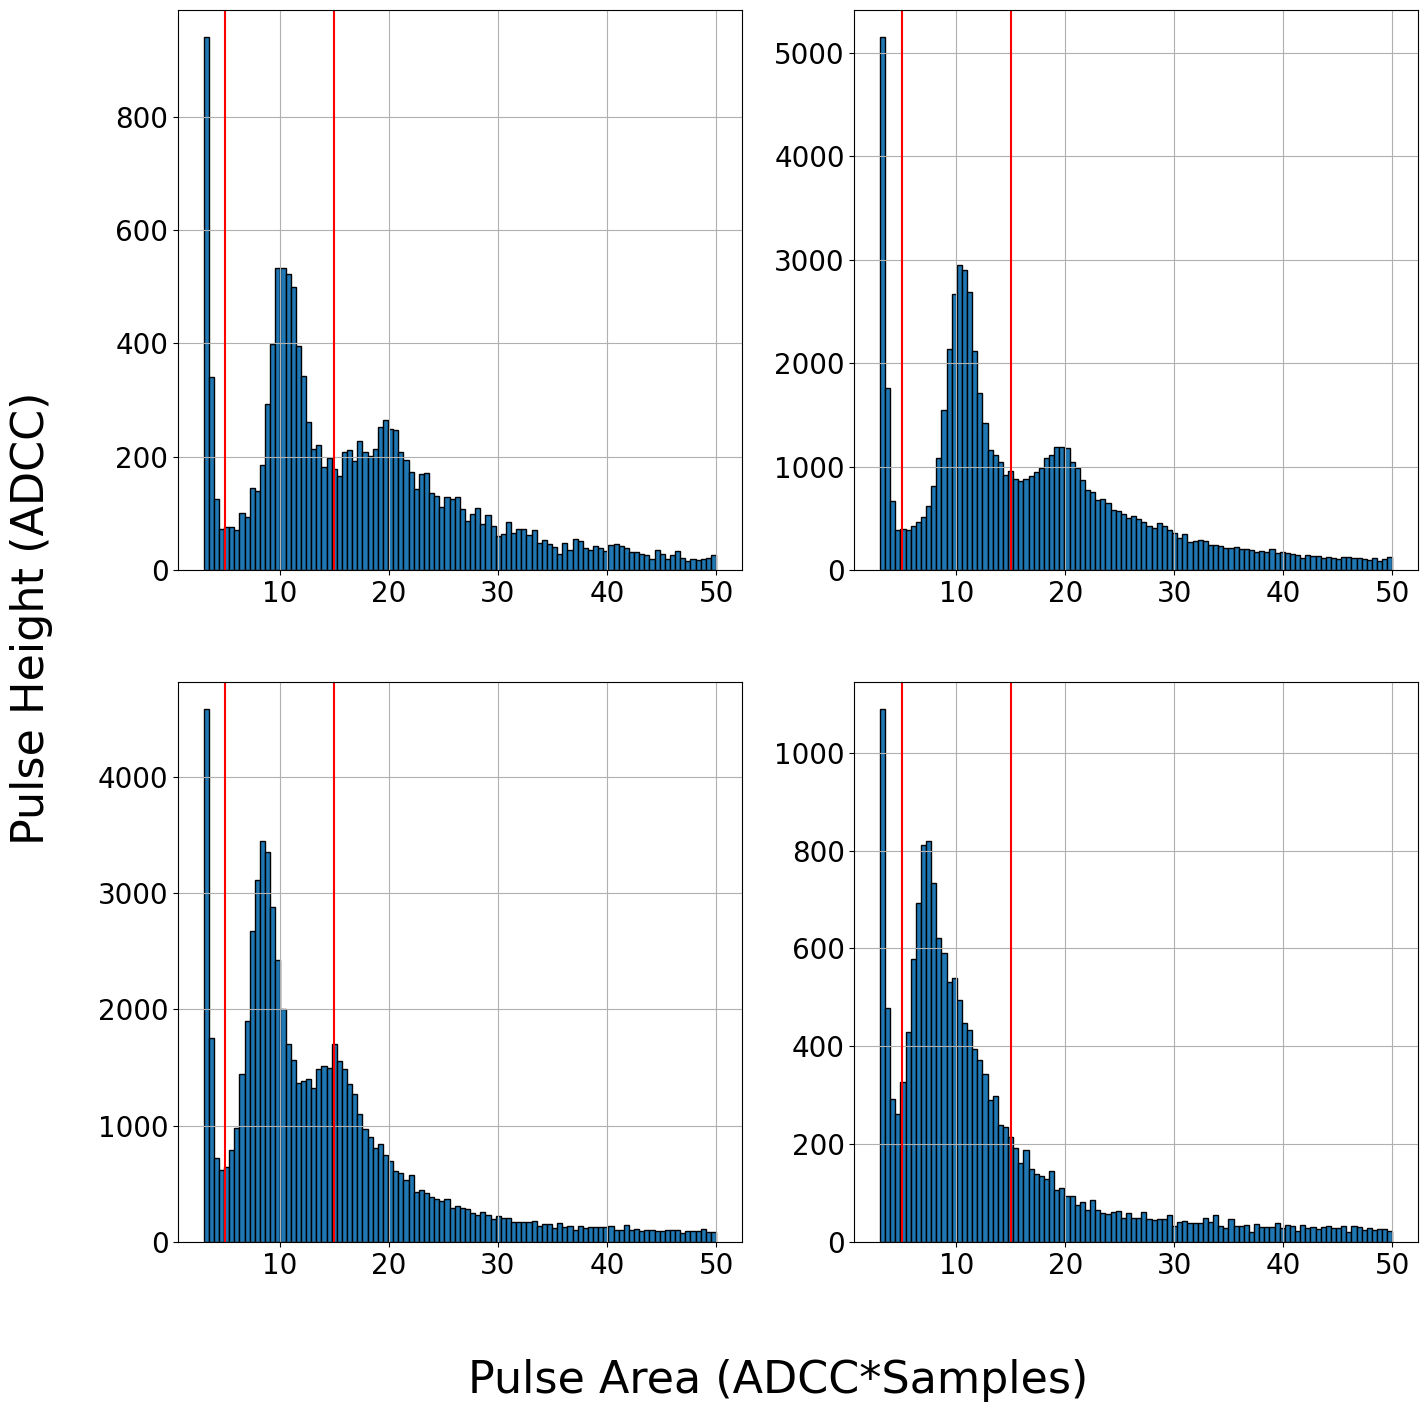

In [208]:
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16,16))
for i in np.arange(len(axs)+2):
    j=i+0
    ax = axs.flatten()
    ax[i].hist(ddict[f'{j}'][1][0],edgecolor='black', bins=100, range=[3,50])
    ax[i].axvline(x=5, color='r')
    ax[i].axvline(x=15, color='r')
    ax[i].grid()
fig.supxlabel('Pulse Area (ADCC*Samples)', fontsize=32)
fig.supylabel('Pulse Height (ADCC)', fontsize=32)
plt.show()

cut_ch_eventids = []
cut_ch_pulseids = []
#for i in np.arange(4):
    #for k in np.arange(32):
        #eventids = ddict[f'{i}'][2][k]
        #pulseids = ddict[f'{i}'][3][k]
        #cut_box = (ddict[f'{i}'][0][k]>180)&(ddict[f'{i}'][0][k]<250)&(ddict[f'{i}'][1][k]>17.5)&(ddict[f'{i}'][1][k]<20.0)
        #cut_ch_eventids.append(eventids[cut_box])
        #cut_ch_pulseids.append(pulseids[cut_box])

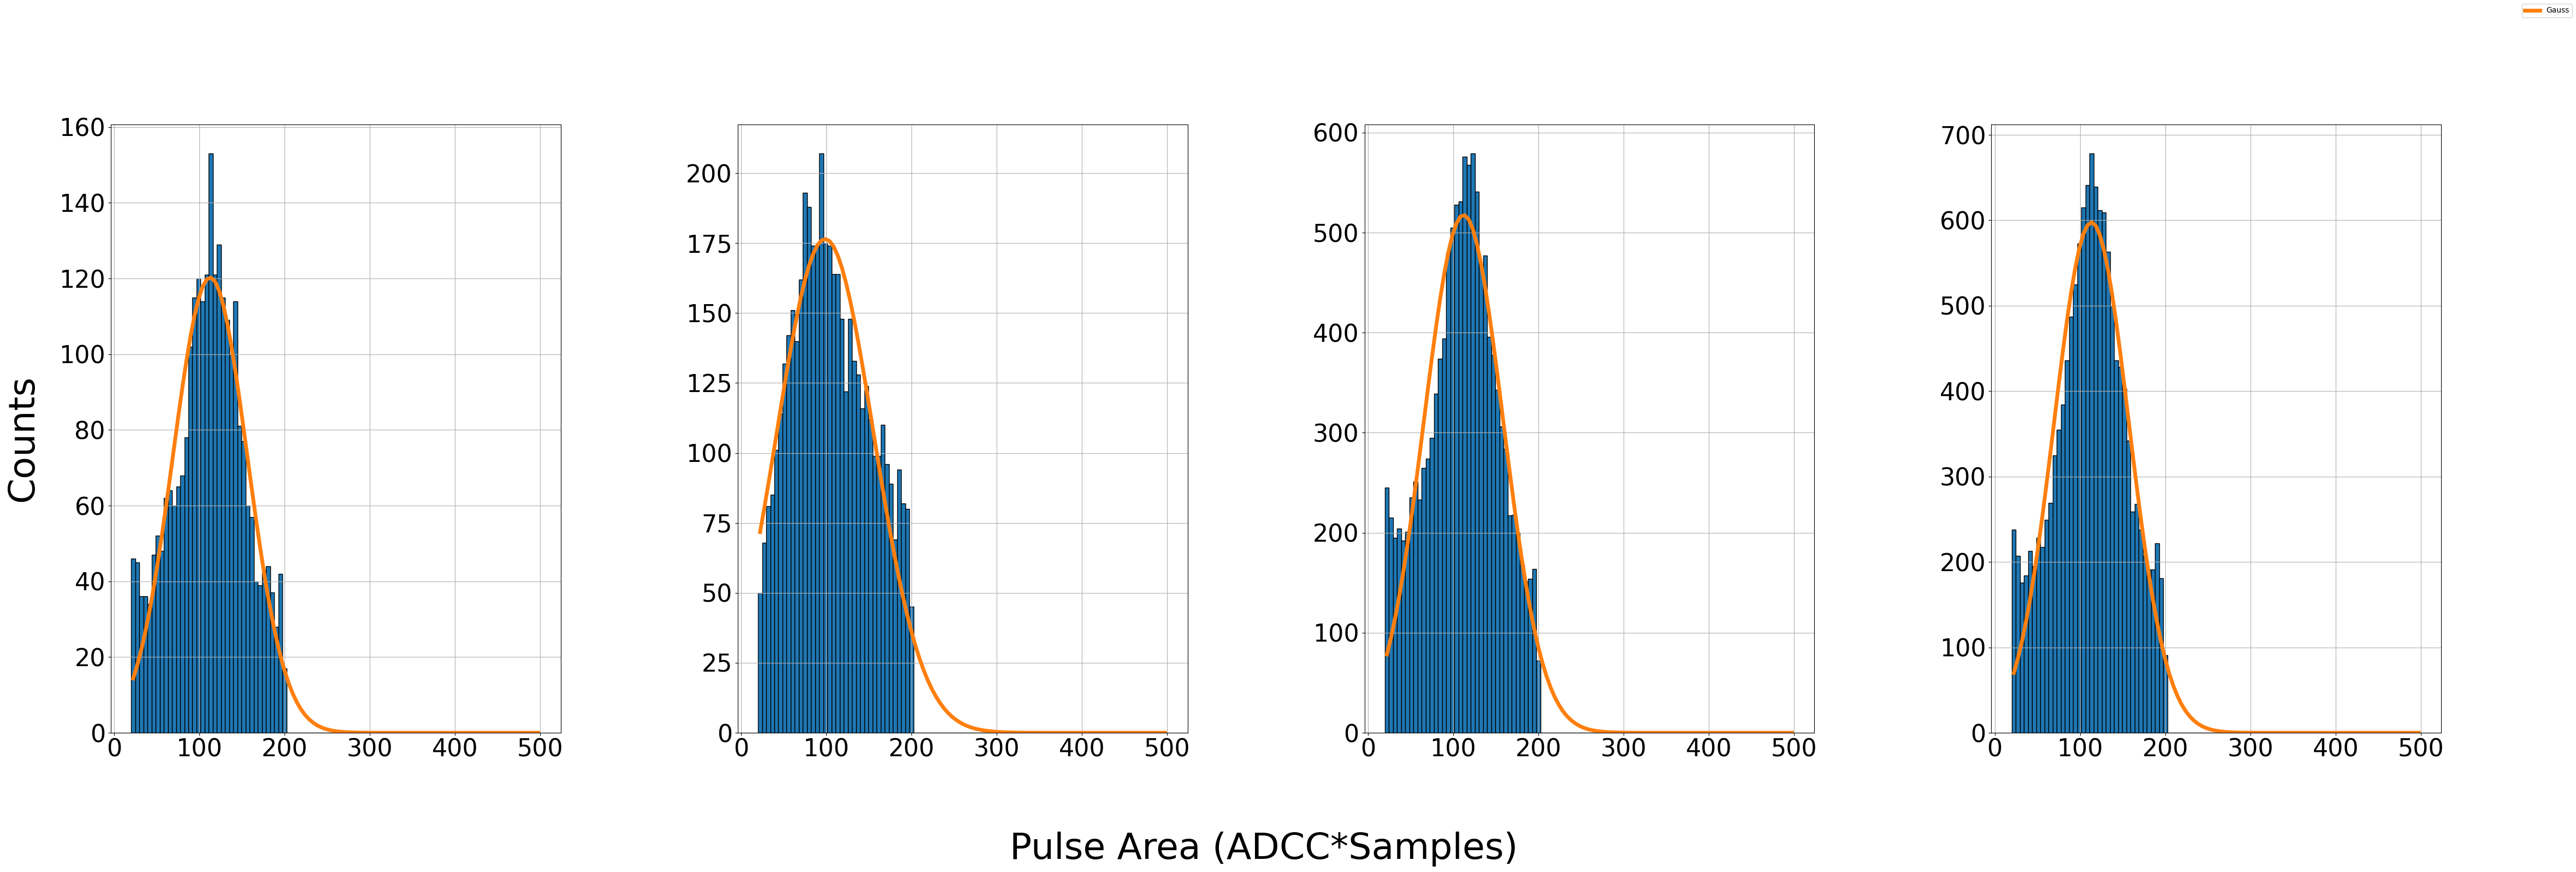

In [ ]:
plt.rc('xtick', labelsize=32)
plt.rc('ytick', labelsize=32)
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(48,16))
plt.tight_layout(pad=15, h_pad=None, w_pad=None, rect=None)
for i in np.arange(4):
    j = i+24
    ax = axs.flatten()
    counts, bins, patches = ax[i].hist(ddict[f'{i}'][4][0], edgecolor='black', bins=100, range=[20,50e1])
    bins = (bins[:-1]+bins[1:])/2
    ax[i].plot(bins, Gaussian(bins, pres[i,0,0], pres[i,0,1], pres[i,0,2]), lw=5)
    #ax[i].set_ylim(0,300)
    ax[i].grid()
fig.supxlabel('Pulse Area (ADCC*Samples)', fontsize=48)
fig.supylabel('Counts', fontsize=48)
plt.show()

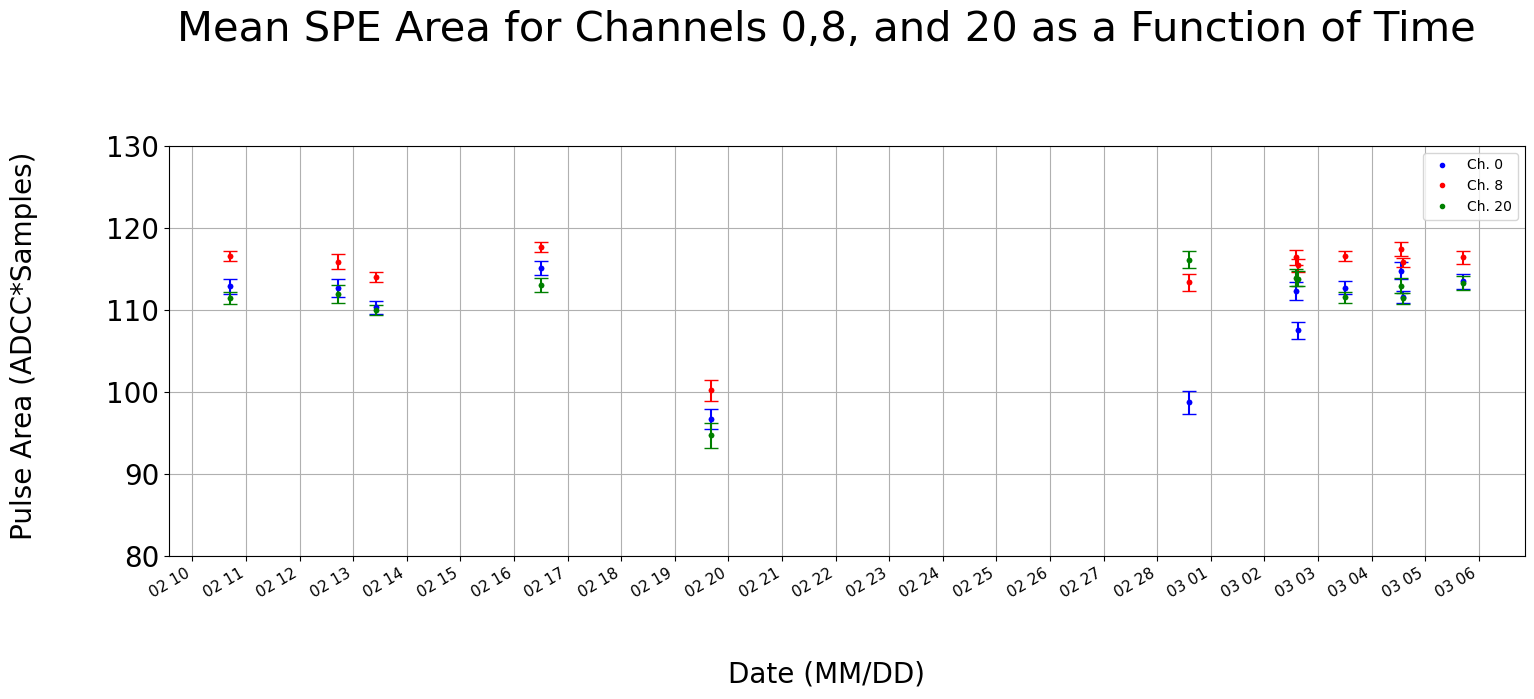

In [211]:
plt.rc('xtick', labelsize=11)
plt.rc('ytick', labelsize=20)
dates = ['2026-02-10-17', '2026-02-12-17', '2026-02-13-10', '2026-02-16-12', '2026-02-19-16', '2026-02-28-14', '2026-03-02-14', '2026-03-02-15', '2026-03-03-12', '2026-03-04-13', '2026-03-04-14', '2026-03-05-17']
time = [datetime.strptime(d, '%Y-%m-%d-%H') for d in dates]

ch = 0
fig, ax = plt.subplots(figsize=(17, 7))
plt.tight_layout(pad=10, h_pad=None, w_pad=None, rect=None)
#ax.plot(time, pres[:,ch::4,2], '.')
ax.plot(time, pres[:,ch,2], '.', color='b')
ax.errorbar(time, pres[:,ch,2], yerr=np.sqrt(err_mean_area[:,ch]), color='b', fmt='.', capsize=5)
ax.plot(time, pres[:,8,2], '.', color='r')
ax.errorbar(time, pres[:,8,2], yerr=np.sqrt(err_mean_area[:,8]), color='r', fmt='.', capsize=5)
ax.plot(time, pres[:,20,2], '.', color='g')
ax.errorbar(time, pres[:,20,2], yerr=np.sqrt(err_mean_area[:,20]), color='g', fmt='.', capsize=5)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m %d'))
ax.set_ylim(80, 130)
ax.grid()
fig.autofmt_xdate() 
fig.supxlabel('Date (MM/DD)', fontsize=20)
fig.supylabel('Pulse Area (ADCC*Samples)', fontsize=20)
fig.suptitle('Mean SPE Area for Channels 0,8, and 20 as a Function of Time',fontsize=30)
plt.legend(['Ch. 0','Ch. 8','Ch. 20'])
plt.show()

In [149]:
print(pres[:,0::4,2])

[[112.87073326 111.09562201 116.54826312 115.15781229 112.02344724
  111.42215192 114.83606077 120.30550512]
 [112.67421113 113.82617565 115.88760612 113.70983483 114.48893458
  111.94726827 116.49808674 121.91826731]
 [110.3248638  106.64400615 114.00182445 113.47425809 113.14442434
  110.01247964 114.66260409 116.68323205]
 [115.1305789  110.67565329 117.67023615 115.57888352 114.73580368
  113.00498556 115.79777819 120.59129857]
 [ 96.72251175  96.50559939 100.19670792  99.55070216  95.56926071
   94.74579677  98.15780352 100.1936066 ]
 [ 98.74028912 111.2413993  113.35071735 109.88124594  98.12376891
  116.11410324 118.65666881 120.29525833]
 [112.28731571 112.32627244 116.39314597 113.47229792 114.17019354
  113.95284559 116.72052344 120.16546066]
 [107.52115228 110.67968598 115.41772954 109.40918335 115.61663389
  113.80903477 115.16442809 121.22567103]
 [112.69557496 112.36555198 116.58896337 113.68415022 113.43137749
  111.56651442 114.62263229 119.57392876]
 [114.80018033 107.

In [150]:
print(pres[:,4,2])

[111.09562201 113.82617565 106.64400615 110.67565329  96.50559939
 111.2413993  112.32627244 110.67968598 112.36555198 107.97304269
 111.29699581 107.87735881]
